In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.15.0
GPU available: []


In [2]:
class MultiOutputVideoGenerator(keras.utils.Sequence):

    def __init__(self, df, video_dir, batch_size=4, num_frames=10, augment=False):
        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir
        self.batch_size = batch_size
        self.num_frames = num_frames
        self.augment = augment
        
        # Build video path cache
        self.video_path_cache = {}
        self.corrupted_videos = []
        self.successful_videos = 0
        self._build_path_cache()
    
    def _build_path_cache(self):
        """Cache video paths for faster lookup"""
        print(f"Building video path cache for {self.video_dir}...")
        
        if not os.path.exists(self.video_dir):
            print(f"Warning: Directory {self.video_dir} does not exist!")
            return
        
        for subject_folder in os.listdir(self.video_dir):
            subject_path = os.path.join(self.video_dir, subject_folder)
            
            if not os.path.isdir(subject_path):
                continue
            
            for video_folder in os.listdir(subject_path):
                video_folder_path = os.path.join(subject_path, video_folder)
                
                if not os.path.isdir(video_folder_path):
                    continue
                
                for file in os.listdir(video_folder_path):
                    if file.endswith('.avi') or file.endswith('.mp4'):
                        full_path = os.path.join(video_folder_path, file)
                        self.video_path_cache[file] = full_path
        
        print(f"Found {len(self.video_path_cache)} videos in cache")
    
    def find_video_path(self, clip_id):
        
        return self.video_path_cache.get(clip_id, None)
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        
        batch_df = self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size]
        
        X = []
        y_dict = {
            'boredom': [],
            'engagement': [],
            'confusion': [],
            'frustration': [],
            'attention_score': []
        }
        
        for _, row in batch_df.iterrows():
            video_path = self.find_video_path(row['ClipID'])
            
            if video_path and os.path.exists(video_path):
                try:
                    frames = self.extract_frames_from_video(video_path, self.num_frames)
                    
                    if len(frames) == self.num_frames:
                        if self.augment:
                            frames = self._augment_frames(frames)
                        
                        X.append(frames)
                        
                        # Append labels for each emotion (0-3)
                        y_dict['boredom'].append(row['Boredom'])
                        y_dict['engagement'].append(row['Engagement'])
                        y_dict['confusion'].append(row['Confusion'])
                        y_dict['frustration'].append(row['Frustration'])
                        y_dict['attention_score'].append(row['attention_score'])
                        
                        self.successful_videos += 1
                except Exception as e:
                    if row['ClipID'] not in self.corrupted_videos:
                        self.corrupted_videos.append(row['ClipID'])
                    continue
        
        # Handle empty batches
        if len(X) == 0:
            X = np.zeros((1, self.num_frames, 224, 224, 3))
            for key in y_dict:
                y_dict[key] = np.zeros(1)
        else:
            X = np.array(X) / 255.0  # Normalize
            for key in y_dict:
                y_dict[key] = np.array(y_dict[key])
        
        return X, y_dict
    
    def extract_frames_from_video(self, video_path, num_frames=10):
        
        cap = None
        try:
            cap = cv2.VideoCapture(video_path)
            
            if not cap.isOpened():
                return np.array([])
            
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            if total_frames < 1:
                cap.release()
                return np.array([])
            
            if total_frames < num_frames:
                num_frames = max(1, total_frames)
            
            frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
            frames = []
            failed_reads = 0
            max_failures = num_frames // 2
            
            for idx in frame_indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                
                if ret and frame is not None:
                    try:
                        frame = cv2.resize(frame, (224, 224))
                        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                        frames.append(frame)
                        failed_reads = 0
                    except Exception:
                        failed_reads += 1
                        if len(frames) > 0:
                            frames.append(frames[-1])
                else:
                    failed_reads += 1
                    if failed_reads > max_failures:
                        break
                    if len(frames) > 0:
                        frames.append(frames[-1])
            
            cap.release()
            
            # Pad if needed
            while len(frames) < num_frames and len(frames) > 0:
                frames.append(frames[-1])
            
            if len(frames) < num_frames // 2:
                return np.array([])
            
            return np.array(frames[:num_frames])
            
        except Exception:
            if cap is not None:
                cap.release()
            return np.array([])
    
    def _augment_frames(self, frames):
        
        if np.random.random() > 0.5:
            frames = np.flip(frames, axis=2)
        
        brightness_factor = np.random.uniform(0.8, 1.2)
        frames = np.clip(frames * brightness_factor, 0, 255)
        
        contrast_factor = np.random.uniform(0.8, 1.2)
        mean = frames.mean()
        frames = np.clip((frames - mean) * contrast_factor + mean, 0, 255)
        
        return frames

print("✓ Multi-output data generator defined")


✓ Multi-output data generator defined


In [3]:
# Load labels
train_df = pd.read_csv('/Users/stevennn/Downloads/DAiSEE/Labels/TrainLabels.csv')
val_df = pd.read_csv('/Users/stevennn/Downloads/DAiSEE/Labels/ValidationLabels.csv')
test_df = pd.read_csv('/Users/stevennn/Downloads/DAiSEE/Labels/TestLabels.csv')

# Fix column names (remove trailing spaces)
train_df.columns = train_df.columns.str.strip()
val_df.columns = val_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Create attention score (0-1 range)
def create_attention_score(df):
    df['attention_score'] = (
        (df['Engagement'] * 0.5 - df['Boredom'] * 0.3 - 
         df['Confusion'] * 0.1 - df['Frustration'] * 0.1) + 3
    ) / 6  # Normalize to 0-1
    return df

train_df = create_attention_score(train_df)
val_df = create_attention_score(val_df)
test_df = create_attention_score(test_df)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

print("\nLabel distribution in training set:")
for col in ['Boredom', 'Engagement', 'Confusion', 'Frustration']:
    print(f"\n{col}:")
    print(train_df[col].value_counts().sort_index())


Training samples: 5358
Validation samples: 1429
Test samples: 1784

Label distribution in training set:

Boredom:
Boredom
0    2433
1    1696
2    1073
3     156
Name: count, dtype: int64

Engagement:
Engagement
0      34
1     213
2    2617
3    2494
Name: count, dtype: int64

Confusion:
Confusion
0    3616
1    1245
2     431
3      66
Name: count, dtype: int64

Frustration:
Frustration
0    4183
1     941
2     191
3      43
Name: count, dtype: int64


In [4]:
import os
import cv2

DATASET_BASE = '/Users/stevennn/Downloads/DAiSEE/DataSet'  

# Create generators
train_gen = MultiOutputVideoGenerator(
    train_df,
    video_dir=os.path.join(DATASET_BASE, 'Train'),
    batch_size=4,
    num_frames=10,
    augment=True
)

val_gen = MultiOutputVideoGenerator(
    val_df,
    video_dir=os.path.join(DATASET_BASE, 'Validation'),
    batch_size=4,
    num_frames=10,
    augment=False
)

print("\n✓ Generators created successfully")
print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")


Building video path cache for /Users/stevennn/Downloads/DAiSEE/DataSet/Train...
Found 5482 videos in cache
Building video path cache for /Users/stevennn/Downloads/DAiSEE/DataSet/Validation...
Found 1720 videos in cache

✓ Generators created successfully
Training batches: 1340
Validation batches: 358


In [5]:
from tensorflow.keras.applications import MobileNetV2

def build_multi_output_model(input_shape=(10, 224, 224, 3)):
    # Input layer
    inputs = layers.Input(shape=input_shape, name='video_input')
    
    # 1. SPATIAL FEATURE EXTRACTION (Transfer Learning)
    # Use MobileNetV2 pre-trained on ImageNet
    # We wrap it in TimeDistributed to apply it to every frame independently
    base_cnn = MobileNetV2(
        weights='imagenet', 
        include_top=False, 
        input_shape=(224, 224, 3)
    )
    
    # Freeze the base initially so we don't destroy pre-trained weights
    base_cnn.trainable = False 
    
    # Apply the CNN to each frame in the sequence
    x = layers.TimeDistributed(base_cnn)(inputs)
    
    # GlobalAveragePooling reduces 7x7x1280 feature map to 1x1280 vector
    # drastically reducing parameters while keeping important info
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x = layers.TimeDistributed(layers.Dropout(0.3))(x) 
    
    # 2. TEMPORAL MODELING
    # Bidirectional LSTM captures patterns in both forward and backward directions
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
    x = layers.Dropout(0.4)(x)
    
    # 3. SHARED DENSE LAYERS
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # 4. TASK-SPECIFIC OUTPUT HEADS
    boredom_output = layers.Dense(4, activation='softmax', name='boredom')(x)
    engagement_output = layers.Dense(4, activation='softmax', name='engagement')(x)
    confusion_output = layers.Dense(4, activation='softmax', name='confusion')(x)
    frustration_output = layers.Dense(4, activation='softmax', name='frustration')(x)
    
    # Continuous attention score (0-1)
    attention_score_output = layers.Dense(1, activation='sigmoid', name='attention_score')(x)
    
    model = models.Model(
        inputs=inputs,
        outputs=[
            boredom_output,
            engagement_output,
            confusion_output,
            frustration_output,
            attention_score_output
        ]
    )
    
    return model

# Create the model
model_multi = build_multi_output_model()
print("✓ Improved Multi-output model created with MobileNetV2 backbone")
model_multi.summary()


✓ Improved Multi-output model created with MobileNetV2 backbone
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 video_input (InputLayer)    [(None, 10, 224, 224, 3)]    0         []                            
                                                                                                  
 time_distributed (TimeDist  (None, 10, 7, 7, 1280)       2257984   ['video_input[0][0]']         
 ributed)                                                                                         
                                                                                                  
 time_distributed_1 (TimeDi  (None, 10, 1280)             0         ['time_distributed[0][0]']    
 stributed)                                                                                       
                              

In [6]:
# Calculating class weights to handle imbalance
def calculate_class_weights(df, column):
    """Calculate weights for imbalanced classes"""
    from sklearn.utils.class_weight import compute_class_weight
    
    classes = np.unique(df[column])
    weights = compute_class_weight('balanced', classes=classes, y=df[column])
    return dict(zip(classes, weights))

# Get class weights for each emotion
boredom_weights = calculate_class_weights(train_df, 'Boredom')
engagement_weights = calculate_class_weights(train_df, 'Engagement')
confusion_weights = calculate_class_weights(train_df, 'Confusion')
frustration_weights = calculate_class_weights(train_df, 'Frustration')

print("Class weights calculated:")
print(f"Boredom: {boredom_weights}")
print(f"Engagement: {engagement_weights}")
print(f"Confusion: {confusion_weights}")
print(f"Frustration: {frustration_weights}")


model_multi.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),  
    loss={
        'boredom': 'sparse_categorical_crossentropy',
        'engagement': 'sparse_categorical_crossentropy',
        'confusion': 'sparse_categorical_crossentropy',
        'frustration': 'sparse_categorical_crossentropy',
        'attention_score': 'mse'  
    },
    loss_weights={
        'boredom': 0.25,
        'engagement': 0.25,
        'confusion': 0.25,
        'frustration': 0.25,
        'attention_score': 1.0  
    },
    metrics={
        'boredom': ['accuracy'],
        'engagement': ['accuracy'],
        'confusion': ['accuracy'],
        'frustration': ['accuracy'],
        'attention_score': ['mae'] 
    }
)

print("\n✓ Model compiled successfully with legacy Adam optimizer")

Class weights calculated:
Boredom: {0: 0.5505548705302096, 1: 0.7897995283018868, 2: 1.2483690587138863, 3: 8.586538461538462}
Engagement: {0: 39.39705882352941, 1: 6.288732394366197, 2: 0.5118456247611769, 3: 0.5370890136327185}
Confusion: {0: 0.3704369469026549, 1: 1.0759036144578313, 2: 3.1078886310904874, 3: 20.295454545454547}
Frustration: {0: 0.3202247191011236, 1: 1.4234856535600424, 2: 7.013089005235602, 3: 31.151162790697676}

✓ Model compiled successfully with legacy Adam optimizer


In [8]:
import os

# Create directory if it doesn't exist
os.makedirs('saved_models/1', exist_ok=True)

callbacks = [
    # Stop training if validation loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when stuck
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    ),
    
    # Save best model 
    keras.callbacks.ModelCheckpoint(
        'saved_models/1/model.h5', 
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
  
    keras.callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )
]
print("✓ Callbacks configured")

✓ Callbacks configured


In [9]:
# Train
history = model_multi.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

Epoch 1/30
 580/1340 [===========>..................] - ETA: 2:47 - loss: 1.4709 - boredom_loss: 1.6513 - engagement_loss: 1.4108 - confusion_loss: 1.4356 - frustration_loss: 1.1780 - attention_score_loss: 0.0520 - boredom_accuracy: 0.3369 - engagement_accuracy: 0.4129 - confusion_accuracy: 0.4357 - frustration_accuracy: 0.5794 - attention_score_mae: 0.1795

[mpeg4 @ 0x105e59060] I cbpy damaged at 16 8
[mpeg4 @ 0x105e59060] Error at MB: 344


1340/1340 [==============================] - ETA: 0s - loss: 1.2135 - boredom_loss: 1.4385 - engagement_loss: 1.1667 - confusion_loss: 1.1719 - frustration_loss: 0.9529 - attention_score_loss: 0.0310 - boredom_accuracy: 0.3664 - engagement_accuracy: 0.4530 - confusion_accuracy: 0.5457 - frustration_accuracy: 0.6762 - attention_score_mae: 0.1328
Epoch 1: val_loss improved from inf to 1.01041, saving model to saved_models/1/model.h5
1340/1340 [==============================] - 360s 266ms/step - loss: 1.2135 - boredom_loss: 1.4385 - engagement_loss: 1.1667 - confusion_loss: 1.1719 - frustration_loss: 0.9529 - attention_score_loss: 0.0310 - boredom_accuracy: 0.3664 - engagement_accuracy: 0.4530 - confusion_accuracy: 0.5457 - frustration_accuracy: 0.6762 - attention_score_mae: 0.1328 - val_loss: 1.0104 - val_boredom_loss: 1.3244 - val_engagement_loss: 1.0216 - val_confusion_loss: 0.8990 - val_frustration_loss: 0.7593 - val_attention_score_loss: 0.0093 - val_boredom_accuracy: 0.3079 - val_en

[mpeg4 @ 0x361ac1bb0] I cbpy damaged at 16 8
[mpeg4 @ 0x361ac1bb0] Error at MB: 344


1340/1340 [==============================] - ETA: 0s - loss: 0.9384 - boredom_loss: 1.1990 - engagement_loss: 0.9114 - confusion_loss: 0.9089 - frustration_loss: 0.7012 - attention_score_loss: 0.0082 - boredom_accuracy: 0.4190 - engagement_accuracy: 0.4714 - confusion_accuracy: 0.6652 - frustration_accuracy: 0.7779 - attention_score_mae: 0.0747
Epoch 2: val_loss did not improve from 1.01041
1340/1340 [==============================] - 357s 266ms/step - loss: 0.9384 - boredom_loss: 1.1990 - engagement_loss: 0.9114 - confusion_loss: 0.9089 - frustration_loss: 0.7012 - attention_score_loss: 0.0082 - boredom_accuracy: 0.4190 - engagement_accuracy: 0.4714 - confusion_accuracy: 0.6652 - frustration_accuracy: 0.7779 - attention_score_mae: 0.0747 - val_loss: 1.0140 - val_boredom_loss: 1.3483 - val_engagement_loss: 0.9913 - val_confusion_loss: 0.9128 - val_frustration_loss: 0.7662 - val_attention_score_loss: 0.0094 - val_boredom_accuracy: 0.3121 - val_engagement_accuracy: 0.5689 - val_confusion

...

1340/1340 [==============================] - ETA: 0s - loss: 0.9134 - boredom_loss: 1.1704 - engagement_loss: 0.8909 - confusion_loss: 0.8835 - frustration_loss: 0.6781 - attention_score_loss: 0.0077 - boredom_accuracy: 0.4324 - engagement_accuracy: 0.4785 - confusion_accuracy: 0.6741 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0723
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_loss did not improve from 1.01041
1340/1340 [==============================] - 356s 265ms/step - loss: 0.9134 - boredom_loss: 1.1704 - engagement_loss: 0.8909 - confusion_loss: 0.8835 - frustration_loss: 0.6781 - attention_score_loss: 0.0077 - boredom_accuracy: 0.4324 - engagement_accuracy: 0.4785 - confusion_accuracy: 0.6741 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0723 - val_loss: 1.0387 - val_boredom_loss: 1.4080 - val_engagement_loss: 1.0448 - val_confusion_loss: 0.8931 - val_frustration_loss: 0.7641 - val_attention_score_loss: 0.0112 - v

[mpeg4 @ 0x361ca8430] I cbpy damaged at 16 8
[mpeg4 @ 0x361ca8430] Error at MB: 344


1340/1340 [==============================] - ETA: 0s - loss: 0.9070 - boredom_loss: 1.1607 - engagement_loss: 0.8820 - confusion_loss: 0.8787 - frustration_loss: 0.6767 - attention_score_loss: 0.0075 - boredom_accuracy: 0.4412 - engagement_accuracy: 0.4748 - confusion_accuracy: 0.6747 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0714
Epoch 5: val_loss did not improve from 1.01041
1340/1340 [==============================] - 354s 264ms/step - loss: 0.9070 - boredom_loss: 1.1607 - engagement_loss: 0.8820 - confusion_loss: 0.8787 - frustration_loss: 0.6767 - attention_score_loss: 0.0075 - boredom_accuracy: 0.4412 - engagement_accuracy: 0.4748 - confusion_accuracy: 0.6747 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0714 - val_loss: 1.0336 - val_boredom_loss: 1.4206 - val_engagement_loss: 1.0184 - val_confusion_loss: 0.8920 - val_frustration_loss: 0.7620 - val_attention_score_loss: 0.0103 - val_boredom_accuracy: 0.3121 - val_engagement_accuracy: 0.5689 - val_confusion

[mpeg4 @ 0x105a9f330] I cbpy damaged at 16 8
[mpeg4 @ 0x105a9f330] Error at MB: 344


1340/1340 [==============================] - ETA: 0s - loss: 0.9030 - boredom_loss: 1.1590 - engagement_loss: 0.8793 - confusion_loss: 0.8744 - frustration_loss: 0.6695 - attention_score_loss: 0.0074 - boredom_accuracy: 0.4423 - engagement_accuracy: 0.4823 - confusion_accuracy: 0.6749 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0711Restoring model weights from the end of the best epoch: 1.

Epoch 6: val_loss did not improve from 1.01041
1340/1340 [==============================] - 336s 251ms/step - loss: 0.9030 - boredom_loss: 1.1590 - engagement_loss: 0.8793 - confusion_loss: 0.8744 - frustration_loss: 0.6695 - attention_score_loss: 0.0074 - boredom_accuracy: 0.4423 - engagement_accuracy: 0.4823 - confusion_accuracy: 0.6749 - frustration_accuracy: 0.7807 - attention_score_mae: 0.0711 - val_loss: 1.0259 - val_boredom_loss: 1.3826 - val_engagement_loss: 1.0270 - val_confusion_loss: 0.8920 - val_frustration_loss: 0.7616 - val_attention_score_loss: 0.0101 - val_boredom_accurac

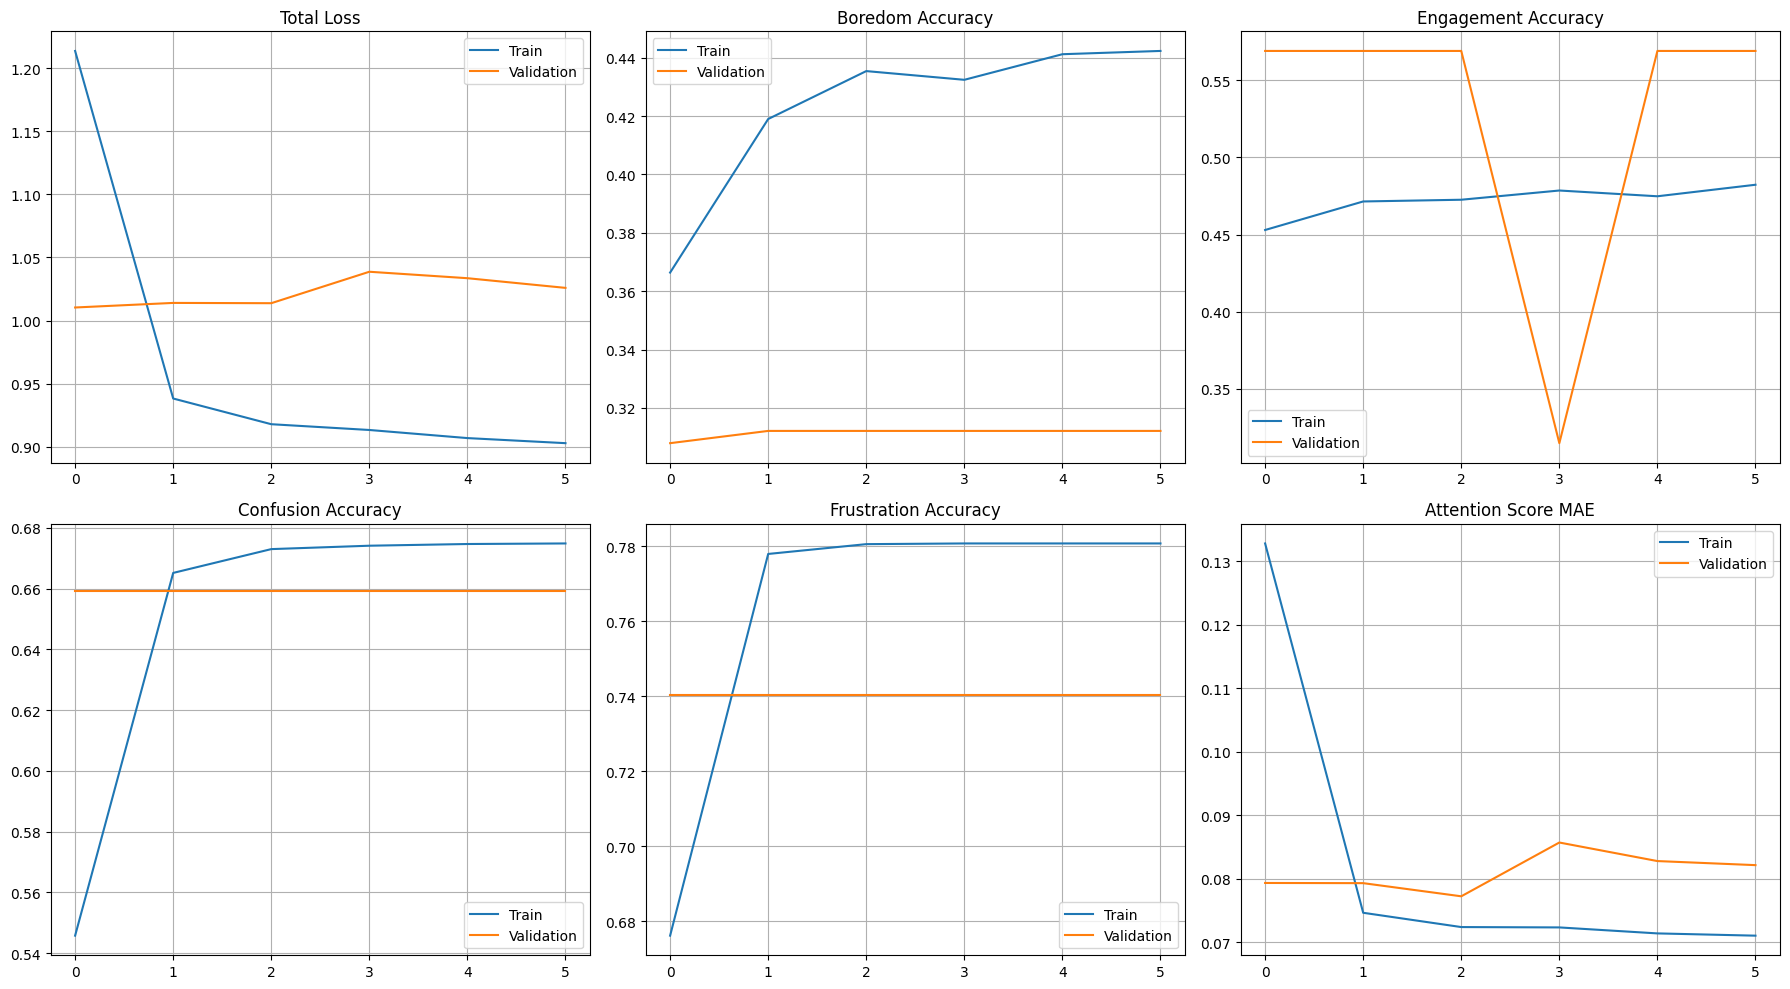

In [10]:
# Plot training history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss plots
axes[0, 0].plot(history.history['loss'], label='Train')
axes[0, 0].plot(history.history['val_loss'], label='Validation')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Boredom accuracy
axes[0, 1].plot(history.history['boredom_accuracy'], label='Train')
axes[0, 1].plot(history.history['val_boredom_accuracy'], label='Validation')
axes[0, 1].set_title('Boredom Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Engagement accuracy
axes[0, 2].plot(history.history['engagement_accuracy'], label='Train')
axes[0, 2].plot(history.history['val_engagement_accuracy'], label='Validation')
axes[0, 2].set_title('Engagement Accuracy')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Confusion accuracy
axes[1, 0].plot(history.history['confusion_accuracy'], label='Train')
axes[1, 0].plot(history.history['val_confusion_accuracy'], label='Validation')
axes[1, 0].set_title('Confusion Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Frustration accuracy
axes[1, 1].plot(history.history['frustration_accuracy'], label='Train')
axes[1, 1].plot(history.history['val_frustration_accuracy'], label='Validation')
axes[1, 1].set_title('Frustration Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Attention score MAE
axes[1, 2].plot(history.history['attention_score_mae'], label='Train')
axes[1, 2].plot(history.history['val_attention_score_mae'], label='Validation')
axes[1, 2].set_title('Attention Score MAE')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()


In [13]:
# ==========================================
# 1. EVALUATE ON TEST SET
# ==========================================
import os
import cv2
import numpy as np

# Create the Test Generator
test_gen = MultiOutputVideoGenerator(
    test_df,
    video_dir=os.path.join('/Users/stevennn/Downloads/DAiSEE/DataSet', 'Test'),
    batch_size=4,
    num_frames=10,
    augment=False
)

print(f"Test batches: {len(test_gen)}")

# Evaluate the model
print("\nEvaluating model on test set... (This may take a few minutes)")
results = model_multi.evaluate(test_gen, verbose=1)

# Print clean results
metrics_names = [
    'Loss', 'Boredom Loss', 'Engagement Loss', 'Confusion Loss', 'Frustration Loss', 'Attention Loss',
    'Boredom Accuracy', 'Engagement Accuracy', 'Confusion Accuracy', 'Frustration Accuracy', 'Attention MAE'
]

print("\n--- FINAL TEST RESULTS ---")
for name, value in zip(metrics_names, results):
    print(f"{name:.<25} {value:.4f}")


# ==========================================
# 2. TEST ON A SINGLE VIDEO
# ==========================================
def predict_single_video(video_path, model, num_frames=10):
    """
    Reads a video file, preprocesses it, and prints the model's prediction.
    """
    if not os.path.exists(video_path):
        print(f"Error: Video not found at {video_path}")
        return

    print(f"\nProcessing video: {video_path}...")
    
    # Extract frames
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames <= 0:
        print("Error: Video is empty or could not be read.")
        return

    # Select frames evenly distributed throughout the video
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    cap.release()
    
    # Pad if we couldn't get enough frames
    while len(frames) < num_frames:
        if len(frames) > 0:
            frames.append(frames[-1])
        else:
            frames.append(np.zeros((224, 224, 3)))
            
    # Normalize and add batch dimension
    X = np.array(frames) / 255.0
    X = np.expand_dims(X, axis=0)  # Shape: (1, 10, 224, 224, 3)
    
    # Predict
    predictions = model.predict(X)
    
    # Unpack predictions (Boredom, Engagement, Confusion, Frustration, Attention)
    boredom = np.argmax(predictions[0])
    engagement = np.argmax(predictions[1])
    confusion = np.argmax(predictions[2])
    frustration = np.argmax(predictions[3])
    attention = predictions[4][0][0]
    
    # Print Prediction
    emotions = {0: "Very Low", 1: "Low", 2: "High", 3: "Very High"}
    
    print("\n--- PREDICTION ---")
    print(f"Boredom:      {boredom} ({emotions.get(boredom, 'Unknown')})")
    print(f"Engagement:   {engagement} ({emotions.get(engagement, 'Unknown')})")
    print(f"Confusion:    {confusion} ({emotions.get(confusion, 'Unknown')})")
    print(f"Frustration:  {frustration} ({emotions.get(frustration, 'Unknown')})")
    print(f"Attention:    {attention:.2%} (Score: {attention:.2f})")

# Replace this path with any real video path you want to test
import random
sample_subject = random.choice(os.listdir(os.path.join(DATASET_BASE, 'Test')))
sample_video_dir = os.path.join(DATASET_BASE, 'Test', sample_subject)
if os.path.isdir(sample_video_dir):
    # Find a video file
    videos = [f for f in os.listdir(sample_video_dir) if f.endswith('.avi') or f.endswith('.mp4')]
    if videos:
        test_video_path = os.path.join(sample_video_dir, videos[0])
        predict_single_video(test_video_path, model_multi)
    else:
        print("No video found in random sample folder.")

Building video path cache for /Users/stevennn/Downloads/DAiSEE/DataSet/Test...
Found 1866 videos in cache
Test batches: 446

Evaluating model on test set... (This may take a few minutes)
446/446 [==============================] - 94s 211ms/step - loss: 0.9016 - boredom_loss: 1.1536 - engagement_loss: 0.8857 - confusion_loss: 0.8727 - frustration_loss: 0.6660 - attention_score_loss: 0.0071 - boredom_accuracy: 0.4619 - engagement_accuracy: 0.4944 - confusion_accuracy: 0.6726 - frustration_accuracy: 0.7780 - attention_score_mae: 0.0710

--- FINAL TEST RESULTS ---
Loss..................... 0.9016
Boredom Loss............. 1.1536
Engagement Loss.......... 0.8857
Confusion Loss........... 0.8727
Frustration Loss......... 0.6660
Attention Loss........... 0.0071
Boredom Accuracy......... 0.4619
Engagement Accuracy...... 0.4944
Confusion Accuracy....... 0.6726
Frustration Accuracy..... 0.7780
Attention MAE............ 0.0710
No video found in random sample folder.


In [14]:
import tensorflow as tf
import os

# 1. Define the export path
export_path = './saved_model_gcp/1'
os.makedirs(export_path, exist_ok=True)

# 2. Save the model in the standard TensorFlow format 
tf.saved_model.save(model_multi, export_path)

print(f"Model saved successfully at: {export_path}")
print("Files generated:")
for root, dirs, files in os.walk(export_path):
    print(f"{root}/")
    for file in files:
        print(f"  - {file}")

INFO:tensorflow:Assets written to: ./saved_model_gcp/1/assets


INFO:tensorflow:Assets written to: ./saved_model_gcp/1/assets


Model saved successfully at: ./saved_model_gcp/1
Files generated:
./saved_model_gcp/1/
  - fingerprint.pb
  - saved_model.pb
./saved_model_gcp/1/variables/
  - variables.data-00000-of-00001
  - variables.index
./saved_model_gcp/1/assets/


In [15]:
import pickle
import os

# Define path
pkl_path = 'engagetrack_model.pkl'

# Save the model
try:
    with open(pkl_path, 'wb') as f:
        pickle.dump(model_multi, f)
    print(f"✓ Model saved as pickle: {pkl_path}")
except Exception as e:
    print(f"Error saving as pickle: {e}")
    print("TensorFlow models are often not pickle-safe. Recommended format is .h5 or SavedModel.")

✓ Model saved as pickle: engagetrack_model.pkl
